### This includes analysis of the outputs from the San Luis Storage, input and output for the Argon national lab study by Quentin.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import os

In [2]:
# Initialize an empty list to store all delta change values
all_changes = []

In [4]:
for year in range(1996, 2024):
    print(year)
    
    for all_years in range(1996,2024):
        
        # Set up the results validation path
        results_folder = f"../Annual_Ensembles/results/{year}/{all_years}"
        
        #Read the input file
        input_data = pd.read_csv(f"{results_folder}/Daily_San_Luis_Outputs.csv", index_col=0)
        
        #Lag the Banks and Tracy Reservoirs
        input_data['Lagged_Storage'] = input_data['Storage'].shift(-1)
        input_data['Lagged_Release'] = input_data['Lagged_Storage'] - input_data['Storage']
        
        #Compute the difference
        input_data['Delta_Change'] = input_data['Inflow'] - input_data['Lagged_Release'] - input_data['Outflow']
        
        #Remove 1st and last values
        #input_data = input_data.iloc[1:-1]
        
        # Add all delta change values to the master list
        all_changes.extend(input_data['Delta_Change'].tolist())


1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023


In [5]:
input_data

,delta_TRP_pump,delta_HRO_pump,Inflow,Storage,Releases,Outflow,Lagged_Storage,Lagged_Release,Delta_Change
2022-10-01,6.592500,2.043742,8.636243,501.134000,0.000000,10.948361,498.821881,-2.312119,-1.776357e-14
2022-10-02,6.745432,0.000000,6.745432,498.821881,2.312119,10.238638,495.328676,-3.493206,2.486900e-14
2022-10-03,7.054186,0.000000,7.054186,495.328676,3.493206,10.248871,492.133992,-3.194684,5.151435e-14
2022-10-04,7.039117,0.000000,7.039117,492.133992,3.194684,9.692639,489.480469,-2.653522,-5.506706e-14
2022-10-05,7.688950,0.000000,7.688950,489.480469,2.653522,11.291717,485.877702,-3.602767,1.243450e-14
...,...,...,...,...,...,...,...,...,...
2023-09-26,8.528926,10.875747,19.404673,1237.970776,1.781772,17.088444,1240.286901,2.316124,1.048939e-04
2023-09-27,8.528926,9.644607,18.173533,1240.286901,-2.316124,17.791051,1240.669361,0.382460,2.202667e-05
2023-09-28,8.528926,10.352884,18.881809,1240.669361,-0.382460,20.453694,1239.097515,-1.571846,-3.833364e-05
2023-09-29,8.528926,13.011519,21.540445,1239.097515,1.571846,21.152243,1239.485821,0.388307,-1.051602e-04


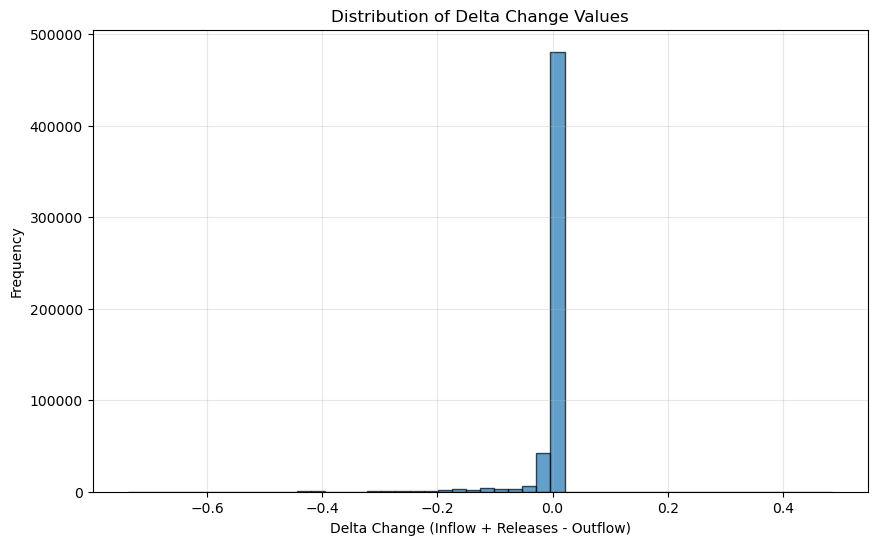

In [6]:
# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(all_changes, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Delta Change (Inflow + Releases - Outflow)')
plt.ylabel('Frequency')
plt.title('Distribution of Delta Change Values')
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
#Remove the storage

for year in range(1996, 2024):
    print(year)
    
    for all_years in range(1996,2024):
        
        # Set up the results validation path
        results_folder = f"../Annual_Ensembles/results/{year}/{all_years}"
        
        #Read the input file
        input_data = pd.read_csv(f"{results_folder}/Daily_San_Luis_Outputs.csv", index_col=0)
        
        #Lag the Banks and Tracy Reservoirs
        input_data['Lagged_Storage'] = input_data['Storage'].shift(-1)
        input_data['Releases'] = input_data['Lagged_Storage'] - input_data['Storage']
        
        #Compute the difference
        input_data['Delta_Change'] = input_data['Inflow'] - input_data['Releases'] - input_data['Outflow']
        input_data.drop('Lagged_Storage', axis=1, inplace=True)
        input_data.drop('Delta_Change', axis=1, inplace=True)
        
        #print(input_data)

        input_data.to_csv(f"{results_folder}/Daily_San_Luis_Outputs.csv", index=True)

1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023


In [8]:
input_data

,delta_TRP_pump,delta_HRO_pump,Inflow,Storage,Releases,Outflow
2022-10-01,6.592500,2.043742,8.636243,501.134000,-2.312119,10.948361
2022-10-02,6.745432,0.000000,6.745432,498.821881,-3.493206,10.238638
2022-10-03,7.054186,0.000000,7.054186,495.328676,-3.194684,10.248871
2022-10-04,7.039117,0.000000,7.039117,492.133992,-2.653522,9.692639
2022-10-05,7.688950,0.000000,7.688950,489.480469,-3.602767,11.291717
...,...,...,...,...,...,...
2023-09-26,8.528926,10.875747,19.404673,1237.970776,2.316124,17.088444
2023-09-27,8.528926,9.644607,18.173533,1240.286901,0.382460,17.791051
2023-09-28,8.528926,10.352884,18.881809,1240.669361,-1.571846,20.453694
2023-09-29,8.528926,13.011519,21.540445,1239.097515,0.388307,21.152243


In [20]:
#Create a San_Luis Folder. Copy from the annual ensemble folder and send to the other one.

for year in range(1996, 2024):
    print(year)
    
    for all_years in range(1996,2024):
        
        # Set up the results validation path
        results_folder = f"../Annual_Ensembles/results/{year}/{all_years}"
        new_folder = f"../Annual_Ensembles/San_Luis/{year}/{all_years}"
        
        #Read the input file
        input_data = pd.read_csv(f"{results_folder}/Daily_San_Luis_Outputs.csv", index_col=0)
        
        #Lag the Banks and Tracy Reservoirs
        input_data['Lagged_Storage'] = input_data['Storage'].shift(-1)
        input_data['Releases'] = input_data['Lagged_Storage'] - input_data['Storage']
        
        #Compute the difference
        input_data['Delta_Change'] = input_data['Inflow'] - input_data['Releases'] - input_data['Outflow']
        input_data.drop('Lagged_Storage', axis=1, inplace=True)
        input_data.drop('Delta_Change', axis=1, inplace=True)
        
        #Clear the repository
        shutil.rmtree(new_folder)
        os.makedirs(new_folder)

        input_data.to_csv(f"{new_folder}/Daily_San_Luis_Outputs.csv", index=True)

1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
